In [ ]:
!pip install -q \
sentence-transformers \
faiss-cpu \
transformers \
datasets \
accelerate \
beautifulsoup4 \
nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 39.3 MB/s eta 0:00:00


In [ ]:
import os
import re
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import nltk
nltk.download("punkt")
from nltk.tokenize import sent_tokenize

import torch
from torch.utils.data import Dataset

from sentence_transformers import SentenceTransformer
import faiss

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
#Importing data
true_df = pd.read_csv('/content/True.csv')
fake_df = pd.read_csv('/content/Fake.csv')

print("True shape:", true_df.shape)
print("Fake shape:", fake_df.shape)

true_df.head()

print("True columns:", true_df.columns)
print("Fake columns:", fake_df.columns)



True shape: (21417, 4)
Fake shape: (17050, 2)
True columns: Index(['title', 'text', 'subject', 'date'], dtype='object')
Fake columns: Index(['type', 'text'], dtype='object')


In [ ]:
#Transforming data into same schema

true_df = true_df[['text']]  # keep only text
true_df['label'] = 1         # 1 = REAL

fake_df = fake_df[['text']]  # keep only text
fake_df['label'] = 0         # 0 = FAKE

print(true_df.head())
print(fake_df.head())


                                                text  label
0  WASHINGTON (Reuters) - The head of a conservat...      1
1  WASHINGTON (Reuters) - Transgender people will...      1
2  WASHINGTON (Reuters) - The special counsel inv...      1
3  WASHINGTON (Reuters) - Trump campaign adviser ...      1
4  SEATTLE/WASHINGTON (Reuters) - President Donal...      1
                                                text  label
0  How soon they forget Obama was called out duri...      0
1  The Breakfast Club interview started out when ...      0
2  After Obama was embarrassed by Donald Trump ac...      0
3  Tune in to the Alternate Current Radio Network...      0
4  Donald Trump flew in an unmarked jet to a meet...      0


In [ ]:
#Combined data set for train, validation & test

df = pd.concat([true_df, fake_df], axis=0)

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.shape

(38467, 2)

Pre-Processing of Data

In [ ]:
#Intial statistics for checking class imbalance
print("Total samples:", len(df))
print("\nLabel distribution:")
print(df['label'].value_counts())

# percentage
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)


Total samples: 38467

Label distribution:
label
1    21417
0    17050
Name: count, dtype: int64

Percentage:
label
1    55.676294
0    44.323706
Name: proportion, dtype: float64


As it is 55% and 45% no class imbalance in data set.

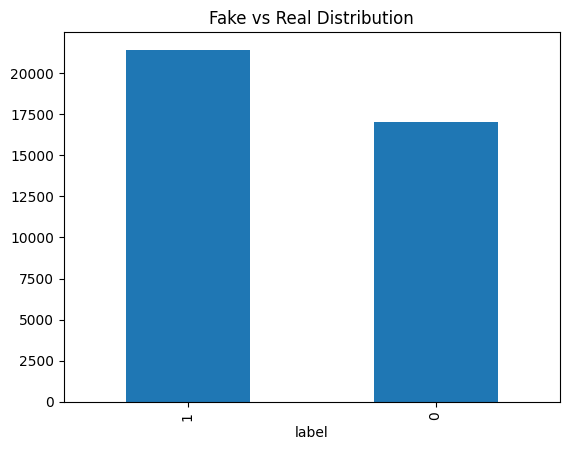

In [ ]:
#Frequency of each label
df['label'].value_counts().plot(kind='bar')
plt.title("Fake vs Real Distribution")
plt.show()


In [ ]:
#Check for blank cells if any
print(df.isnull().sum())

#Correction for blank cells

df.dropna(inplace=True)
print("After drop:", df.shape)


text     0
label    0
dtype: int64
After drop: (38467, 2)


In [ ]:
#Text Cleanign function

def clean_text(text):

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
#Applying text cleaning function

df['clean_text'] = df['text'].apply(clean_text)

df.shape


(38467, 3)

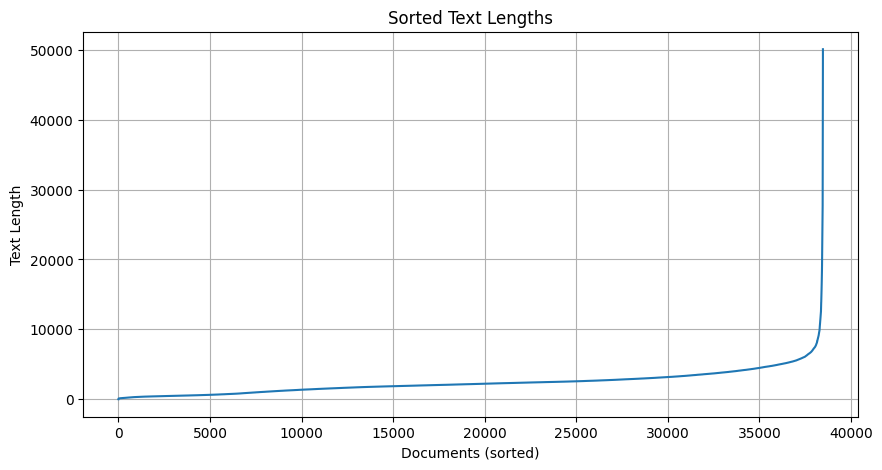

In [ ]:
# Minimum Threshold length for selecting data into training model.
#Method-1 Elbow method

import numpy as np
import matplotlib.pyplot as plt

lengths = df['clean_text'].str.len().dropna()

sorted_lengths = np.sort(lengths)

plt.figure(figsize=(10,5))
plt.plot(sorted_lengths)
plt.xlabel("Documents (sorted)")
plt.ylabel("Text Length")
plt.title("Sorted Text Lengths")
plt.grid(True)
plt.show()

In [ ]:
!pip install kneed

Suggested threshold: 10369


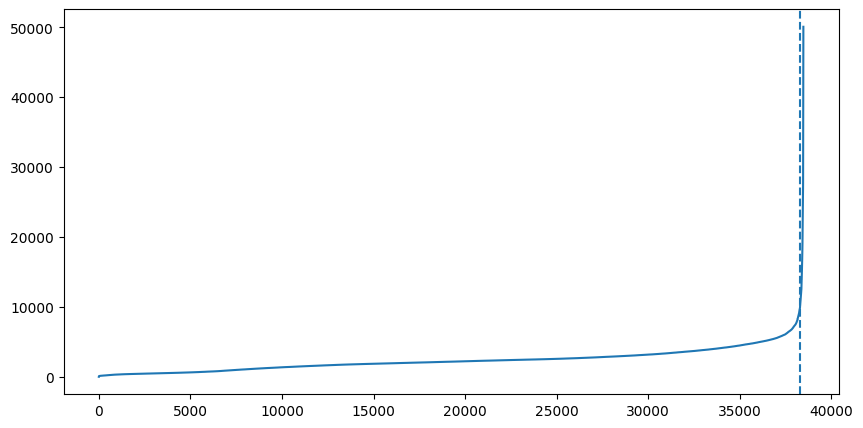

In [ ]:
#Kneel locator for idenitfying best length for considering for analysis
#Method-2: Kneel locator

from kneed import KneeLocator
import numpy as np

lengths = np.sort(df['clean_text'].str.len())

x = range(len(lengths))
y = lengths

kneedle = KneeLocator(x, y, curve='convex', direction='increasing')

print("Suggested threshold:", y[kneedle.knee])

plt.figure(figsize=(10,5))
plt.plot(x, y)
plt.axvline(kneedle.knee, linestyle='--')
plt.show()

In [ ]:
# Percentile Method
print(df['clean_text'].str.len().quantile([0.01, 0.05, 0.1, 0.2]))

0.01     202.0
0.05     408.0
0.10     538.0
0.20    1013.0
Name: clean_text, dtype: float64


In [ ]:
#Considered top 80% of data, Removed some short text for reducing model training complexity.
df = df[df['clean_text'].str.len() > 3000]

print("Final dataset shape:", df.shape)


Final dataset shape: (9593, 3)


In [ ]:
#Checking for duplicates

df.duplicated()

,0
2,False
4,False
9,False
16,False
19,False
...,...
38445,False
38449,False
38453,False
38461,False


In [ ]:
# Removing sources like Reuters and all

def remove_news_patterns(text):
    text = re.sub(r'\(reuters\)', '', text, flags=re.IGNORECASE)
    text = re.sub(r'AP News', '', text, flags=re.IGNORECASE)
    return text

df['clean_text'] = df['clean_text'].apply(remove_news_patterns)


In [ ]:
# For BERT embedding, RAG and Gen AI inferences, better to have both raw data and processed data in a single data frame, as BERT, RAG are done on raw data and LSTM can be done on processed data

df['raw_text'] = df['text']         # original
df['clean_text'] = df['clean_text'] # processed

df.shape

(9593, 4)

<Axes: >

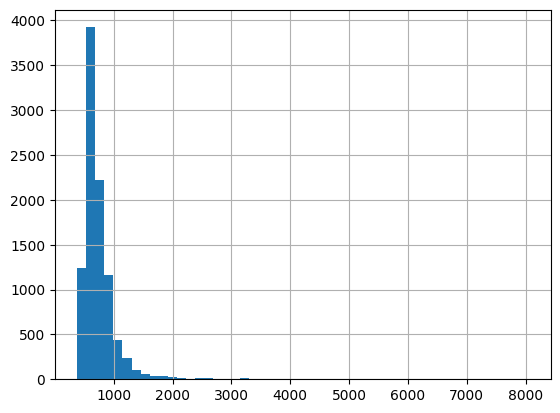

In [ ]:
#Text length analysis for creating trucation during embeddings

df['length'] = df['clean_text'].apply(lambda x: len(x.split()))

df['length'].hist(bins=50)


As per above, majority of embeddinds can be covereded under 512, hence max lenght of BERT, i.e. 512 tokens can be taken.

In [ ]:
!pip install torch torchvision torchaudio
!pip install transformers datasets evaluate accelerate sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.1 MB/s eta 0:00:00


In [ ]:
!pip install beautifulsoup4

In [ ]:
!pip install nltk

In [ ]:
# Random state reproducability
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


In [ ]:
# Keep length features
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))
df["char_count"] = df["clean_text"].apply(len)

df = df.reset_index(drop=True)

print("Final processed shape:", df.shape)
print(df[["raw_text", "clean_text", "label"]].head())

Final processed shape: (9593, 7)
                                            raw_text  \
0  WASHINGTON (Reuters) - President Donald Trump ...   
1  CARACAS (Reuters) - Venezuelan President Nicol...   
2  SHANGHAI (Reuters) - The chairman of the Senat...   
3  BET EL, West Bank (Reuters) - For many in the ...   
4  SEOUL (Reuters) - South Korea approved a plan ...   

                                          clean_text  label  
0  washington reuters president donald trump is s...      1  
1  caracas reuters venezuelan president nicolas m...      1  
2  shanghai reuters the chairman of the senate ju...      1  
3  bet el west bank reuters for many in the israe...      1  
4  seoul reuters south korea approved a plan on t...      1  


In [ ]:
df.columns

Index(['text', 'label', 'clean_text', 'raw_text', 'length', 'word_count',
       'char_count'],
      dtype='object')

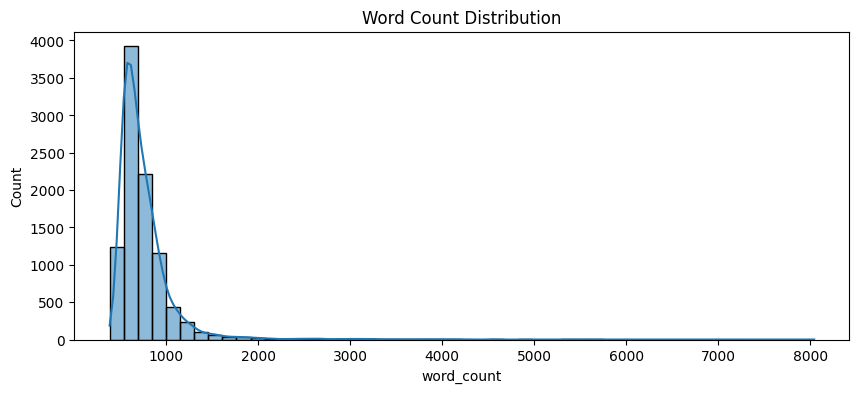

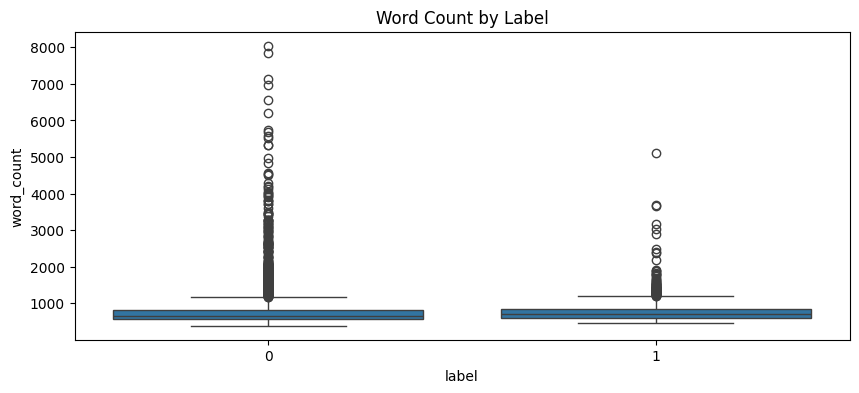

In [ ]:
#Text length distribution


plt.figure(figsize=(10,4))
sns.histplot(df["word_count"], bins=50, kde=True)
plt.title("Word Count Distribution")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x="label", y="word_count", data=df)
plt.title("Word Count by Label")
plt.show()


In [ ]:
#Train, test and validation split (70%, 15% and 15%)

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label"])

val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"])

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (6715, 7)
Validation: (1439, 7)
Test: (1439, 7)


In [ ]:
#Chunking for best tokenization - Considered semantic

def semantic_chunking(text, threshold=0.75, max_chunk_size=5):
    """
    Splits text into semantically coherent chunks using sentence embeddings.
    """
    sentences = sent_tokenize(str(text))

    if len(sentences) == 0:
        return []

    # Get embeddings for sentences
    sentence_embeddings = semantic_embedder.encode(sentences)

    chunks = []
    current_chunk = [sentences[0]]

    for i in range(1, len(sentences)):
        prev_emb = sentence_embeddings[i-1]
        curr_emb = sentence_embeddings[i]

        # Cosine similarity
        similarity = np.dot(prev_emb, curr_emb) / (
            np.linalg.norm(prev_emb) * np.linalg.norm(curr_emb)
        )

        # If similar → same chunk
        if similarity >= threshold and len(current_chunk) < max_chunk_size:
            current_chunk.append(sentences[i])
        else:
            chunks.append(" ".join(current_chunk))
            current_chunk = [sentences[i]]

    # Add last chunk
    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

In [ ]:
#Applying above chunking to data

import nltk
nltk.download('punkt_tab')

semantic_embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Replace old chunking
train_df["chunks"] = train_df["raw_text"].apply(semantic_chunking)
val_df["chunks"] = val_df["raw_text"].apply(semantic_chunking)
test_df["chunks"] = test_df["raw_text"].apply(semantic_chunking)

train_df[["raw_text", "chunks"]].head(2)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Data into arrays for reducing complexity

X_train_clean = train_df["clean_text"].tolist()
y_train = train_df["label"].tolist()

X_val_clean = val_df["clean_text"].tolist()
y_val = val_df["label"].tolist()

X_test_clean = test_df["clean_text"].tolist()
y_test = test_df["label"].tolist()

X_train_raw = train_df["raw_text"].tolist()
X_val_raw = val_df["raw_text"].tolist()
X_test_raw = test_df["raw_text"].tolist()

In [ ]:
# Function for computation metrics, for model comparison

def compute_metrics_from_preds(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    mp, mr, mf1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    return {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "macro_f1": mf1
    }

def print_metrics(name, metrics_dict):
    print(f"\n{name}")
    for k, v in metrics_dict.items():
        print(f"{k}: {v:.2f}")

In [ ]:
#Embedding after chunking
embedding_model_name = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(embedding_model_name, device=DEVICE)

# Example embeddings on a small subset
sample_embeddings = embedder.encode(train_df["raw_text"].iloc[:10].tolist(), normalize_embeddings=True)
print("Embedding shape:", sample_embeddings.shape)

In [ ]:
# Traditional ML Models - For baseline metrics

baseline_models = {
    "logreg": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
        ("clf", LogisticRegression(max_iter=2000))
    ]),
    "linear_svm": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
        ("clf", LinearSVC())
    ]),
    "naive_bayes": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
        ("clf", MultinomialNB())
    ]),
}

baseline_results = {}
trained_baselines = {}

for name, model in baseline_models.items():
    print(f"Training {name}...")
    model.fit(X_train_clean, y_train)
    val_preds = model.predict(X_val_clean)
    metrics_dict = compute_metrics_from_preds(y_val, val_preds)
    baseline_results[name] = metrics_dict
    trained_baselines[name] = model
    print_metrics(name, metrics_dict)

baseline_results_df = pd.DataFrame(baseline_results).T.sort_values("macro_f1", ascending=False)
baseline_results_df

In [ ]:
# Improved tokenization

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 50000
MAX_LEN = 512

keras_tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train_clean)

X_train_seq = keras_tokenizer.texts_to_sequences(X_train_clean)
X_val_seq = keras_tokenizer.texts_to_sequences(X_val_clean)
X_test_seq = keras_tokenizer.texts_to_sequences(X_test_clean)

print("Sample sequence:", X_train_seq[0][:20])
print("Empty sequences:", sum(len(x)==0 for x in X_train_seq))

In [ ]:
# Padding and truncating

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

y_train_np = np.array(y_train)
y_val_np = np.array(y_val)
y_test_np = np.array(y_test)

print(X_train_pad.shape)

In [ ]:
# Bidirectional LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input

bilstm_model = Sequential([
    Input(shape=(512,)),

    Embedding(input_dim = MAX_VOCAB, output_dim=128),

    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(32)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

In [ ]:
# Training NLP model

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = bilstm_model.fit(
    X_train_pad,
    y_train_np,
    validation_data=(X_val_pad, y_val_np),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop]
)

In [ ]:
# Model evaluation

# Predict on validation set
val_probs_bilstm = bilstm_model.predict(X_val_pad).ravel()

# Convert probabilities → labels
val_preds_bilstm = (val_probs_bilstm >= 0.5).astype(int)

# Compute metrics
bilstm_metrics = compute_metrics_from_preds(y_val_np, val_preds_bilstm)

# Print
print_metrics("BiLSTM", bilstm_metrics)


Transformer Model

In [ ]:
# Model taken and tokenizer

MODEL_NAME = "distilbert-base-uncased"
# You can change to "bert-base-uncased" or "roberta-base"

hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
train_df["transformer_text"] = train_df["clean_text"]
val_df["transformer_text"] = val_df["clean_text"]
test_df["transformer_text"] = test_df["clean_text"]

In [ ]:
#Data wrapper for hugging face

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item

train_dataset_hf = NewsDataset(train_df["transformer_text"], train_df["label"], hf_tokenizer)
val_dataset_hf = NewsDataset(val_df["transformer_text"], val_df["label"], hf_tokenizer)
test_dataset_hf = NewsDataset(test_df["transformer_text"], test_df["label"], hf_tokenizer)

In [ ]:
# Evaluation metrics

def hf_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    mp, mr, mf1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    return {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "macro_f1": mf1
    }

In [ ]:
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./transformer_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate = 0.01,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=train_dataset_hf,
    eval_dataset=val_dataset_hf,
    processing_class=hf_tokenizer,
    compute_metrics=hf_compute_metrics
)

trainer.train()

In [ ]:
#Evaluation of model

transformer_eval = trainer.evaluate(val_dataset_hf)
transformer_metrics = {
    "accuracy": transformer_eval["eval_accuracy"],
    "precision": transformer_eval["eval_precision"],
    "recall": transformer_eval["eval_recall"],
    "f1": transformer_eval["eval_f1"],
    "macro_f1": transformer_eval["eval_macro_f1"]
}

print_metrics("Transformer", transformer_metrics)

In [ ]:
# Comparing all models

all_results = baseline_results_df.copy()
all_results.loc["bilstm"] = bilstm_metrics
all_results.loc["transformer"] = transformer_metrics

all_results = all_results.sort_values("macro_f1", ascending=False)
all_results

In [ ]:
#Picking up the best model

best_model_name = all_results.index[0]
print("Best model based on validation macro_f1:", best_model_name)

best_model_name

In [ ]:
# Test set evaluation on chosen model

def evaluate_on_test(best_model_name):
    if best_model_name in trained_baselines:
        model = trained_baselines[best_model_name]
        preds = model.predict(X_test_clean)
        metrics_dict = compute_metrics_from_preds(y_test, preds)
        return preds, metrics_dict

    elif best_model_name == "bilstm":
        probs = bilstm_model.predict(X_test_pad).ravel()
        preds = (probs >= 0.5).astype(int)
        metrics_dict = compute_metrics_from_preds(y_test_np, preds)
        return preds, metrics_dict

    elif best_model_name == "transformer":
        pred_output = trainer.predict(test_dataset_hf)
        preds = np.argmax(pred_output.predictions, axis=1)
        metrics_dict = compute_metrics_from_preds(test_df["label"].values, preds)
        return preds, metrics_dict

    else:
        raise ValueError("Unknown model")

test_preds, test_metrics = evaluate_on_test(best_model_name)
print_metrics(f"TEST RESULTS: {best_model_name}", test_metrics)
print("\nClassification Report:")
print(classification_report(y_test, test_preds))

In [ ]:
# helper function for extracting key sentences

def baseline_predict_proba_like(model_baseline, texts):
    if hasattr(model_baseline, "predict_proba"):
        probs = model_baseline.predict_proba(texts)[:, 1]
    elif hasattr(model_baseline, "decision_function"):
        scores = model_baseline.decision_function(texts)
        probs = 1 / (1 + np.exp(-scores))
    else:
        preds = model_baseline.predict(texts)
        probs = np.array(preds, dtype=float)
    return probs

def predict_text_probability(text):

    print("Input type:", type(text))

    text = str(text)

    if best_model_name in trained_baselines:

        model_baseline = trained_baselines[best_model_name]

        print("Model type:", type(model_baseline))

        prob_real = baseline_predict_proba_like(
            model_baseline,
            [text]
        )[0]

        pred = int(prob_real >= 0.5)

        return pred, float(prob_real)

    if best_model_name == "bilstm":
        seq = keras_tokenizer.texts_to_sequences([text])
        pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
        prob_real = float(bilstm_model.predict(pad, verbose=0).ravel()[0])
        pred = int(prob_real >= 0.5)
        return pred, prob_real

    elif best_model_name == "transformer":
        enc = hf_tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt"
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        transformer_model_local = trainer.model.to(DEVICE)
        transformer_model_local.eval()
        with torch.no_grad():
            out = transformer_model_local(**enc)
            probs = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        pred = int(np.argmax(probs))
        prob_real = float(probs[1])  # class 1 = real
        return pred, prob_real

In [ ]:
# Final extraction of key sentences for checking fake or not

def extract_key_sentences(article_text, top_k=3):
    sentences = safe_sent_tokenize(article_text)
    sentence_scores = []

    if len(sentences) == 0:
        return []

    overall_pred, overall_prob = predict_text_probability(article_text)

    for sent in sentences:
        if len(sent.split()) < 4:
            continue
        sent_pred, sent_prob = predict_text_probability(sent)

        if overall_pred == 1:  # article predicted real
            score = sent_prob if sent_pred == 1 else 0.0
        else:  # article predicted fake
            score = (1 - sent_prob) if sent_pred == 0 else 0.0

        sentence_scores.append((sent, score))

    sentence_scores = sorted(sentence_scores, key=lambda x: x[1], reverse=True)
    return sentence_scores[:top_k]

In [ ]:
import nltk
import re
nltk.download('punkt', quiet=True)
def safe_sent_tokenize (text):
    try:
        return nltk.sent_tokenize(text)
    except:
        return re.split(r'(?<=[.!?])\s+', text)

In [ ]:
# Testing sentence extraction
sample_article = test_df["raw_text"].iloc[0]
sample_label = test_df["label"].iloc[0]

print("True label:", sample_label)
pred, prob_real = predict_text_probability(sample_article)
print("Predicted label:", pred)
print("Probability real:", round(prob_real, 4))

top_sents = extract_key_sentences(sample_article, top_k=3)

for i, (sent, score) in enumerate(top_sents, 1):
    print(f"\n[{i}] score={score:.4f}")
    print(sent)

Till now, worked on ISOT dataset for identification of Fake news. From Now, to get the AI Summaries, we are using dataset of LIAR which contains factual data. From the above sentence extraction process, we get key sentences as to why the article is fake or not. From those key sentences it is compared with factual data of LIAR dataset for providing explanation. So, we are ysing RAG technique to get the data from LIAR and compare it with the sentence that are extracted and accordingly generate response through any model.

In [ ]:
# Loading semantic embedding model for RAG

from sentence_transformers import SentenceTransformer

embedding_model_name = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(embedding_model_name, device=DEVICE)

print("Embedding model ready:", embedding_model_name)

In [ ]:
# Loading dataset of LIAR for factual information

liar_train_path = "/content/train.tsv"
liar_valid_path = "/content/valid.tsv"
liar_test_path = "/content/test.tsv"

liar_columns = [
    "id", "label", "statement", "subject", "speaker", "job_title",
    "state_info", "party_affiliation",
    "barely_true_counts", "false_counts", "half_true_counts",
    "mostly_true_counts", "pants_on_fire_counts", "context"
]

liar_train = pd.read_csv(liar_train_path, sep="\t", header=None, names=liar_columns)
liar_valid = pd.read_csv(liar_valid_path, sep="\t", header=None, names=liar_columns)
liar_test = pd.read_csv(liar_test_path, sep="\t", header=None, names=liar_columns)

liar_df = pd.concat([liar_train, liar_valid, liar_test], axis=0).reset_index(drop=True)

print(liar_df.shape)
liar_df.head()

In [ ]:
# Build LIAR retrieval text

def safe_str(x):
    return "" if pd.isnull(x) else str(x)

liar_df["statement_clean"] = liar_df["statement"].astype(str)

liar_df["retrieval_text"] = liar_df.apply(
    lambda row: (
        f"statement: {safe_str(row.get('statement', ''))} | "
        f"label: {safe_str(row.get('label', ''))} | "
        f"subject: {safe_str(row.get('subject', ''))} | "
        f"speaker: {safe_str(row.get('speaker', ''))} | "
        f"party: {safe_str(row.get('party_affiliation', ''))} | "
        f"context: {safe_str(row.get('context', ''))}"
    ),
    axis=1
)

liar_df = liar_df[liar_df["statement_clean"].str.len() > 5].copy()
liar_df = liar_df.reset_index(drop=True)

liar_df[["statement", "label", "retrieval_text"]].head()

In [ ]:
# Embedding LIAR and FAISS Index for priority

import numpy as np
import faiss
liar_texts = liar_df["retrieval_text"].tolist()
liar_embeddings = embedder.encode(liar_texts,batch_size=64,show_progress_bar=True,normalize_embeddings=True)
liar_dimension = liar_embeddings.shape[1]
liar_index = faiss. IndexFlatIP(liar_dimension)
liar_index.add(np.array(liar_embeddings).astype("float32"))
print("LIAR embeddings shape:", liar_embeddings.shape)
print("LIAR index size:", liar_index.ntotal)

In [ ]:
# Retrieval function of LIAR

def retrieve_liar_claims(query_text, top_k=5):

    query_emb = embedder.encode(
        [query_text],
        normalize_embeddings=True
    )

    scores, indices = liar_index.search(
        np.array(query_emb).astype("float32"),
        top_k
    )

    results = []

    for score, idx in zip(scores[0], indices[0]):

        row = liar_df.iloc[idx]

        results.append({
            "score": float(score),
            "statement": row["statement"],
            "label": row["label"],
            "subject": row["subject"],
            "speaker": row["speaker"],
            "party_affiliation": row["party_affiliation"],
            "context": row["context"]
        })

    return results

In [ ]:
# Building RAG corpus from semantic chunks

news_chunk_records = []

for idx, row in train_df.iterrows():
    label = row["label"]
    chunks = row["chunks"]

    for cid, chunk in enumerate(chunks):
        if len(str(chunk).split()) < 20:
            continue
        news_chunk_records.append({
            "article_id": idx,
            "chunk_id": cid,
            "label": label,
            "chunk_text": chunk
        })

news_chunks_df = pd.DataFrame(news_chunk_records)
print(news_chunks_df.shape)
news_chunks_df.head()

In [ ]:
# Embed news chunks and FAISS

news_chunk_texts = news_chunks_df["chunk_text"].tolist()

news_chunk_embeddings = embedder.encode(
    news_chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

news_dimension = news_chunk_embeddings.shape[1]
news_index = faiss.IndexFlatIP(news_dimension)
news_index.add(np.array(news_chunk_embeddings).astype("float32"))

print("News chunk index size:", news_index.ntotal)

In [ ]:
# Retrieving Similar new chunks based on factual information

def retrieve_news_chunks(query_text, top_k=5):
    query_emb = embedder.encode([query_text], normalize_embeddings=True)
    scores, indices = news_index.search(np.array(query_emb).astype("float32"), top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        row = news_chunks_df.iloc[idx]
        results.append({
            "score": float(score),
            "label": int(row["label"]),
            "chunk_text": row["chunk_text"],
            "article_id": int(row["article_id"]),
            "chunk_id": int(row["chunk_id"])
        })
    return results

In [ ]:
pip install google-generativeai

In [ ]:
# Loading LLM For Explanation. To be checked

import google.generativeai as genai

GEMINI_API_KEY = "Key"

genai.configure(
    api_key=GEMINI_API_KEY
)

gemini_model = genai.GenerativeModel(
    "gemini-1.5-flash"
)

print("Gemini Loaded Successfully")

In [ ]:
# Building explanation prompt

def build_explanation_prompt(
    article_text,
    predicted_label,
    confidence,
    key_sentences,
    liar_hits,
    news_hits=None
):

    verdict = "REAL" if predicted_label == 1 else "FAKE"

    key_sent_text = "\n".join([
        f"- {sent}"
        for sent, score in key_sentences[:3]
    ])

    liar_text = "\n".join([
        f"- {hit['statement']} ({hit['label']})"
        for hit in liar_hits[:3]
    ])

    news_text = "\n".join([
        f"- {hit['chunk_text'][:250]}"
        for hit in (news_hits[:2] if news_hits else [])
    ])

    return f"""
You are an expert fact-checking assistant.

Analyze the article, model prediction, retrieved fact-check evidence,
and similar news evidence.

ARTICLE:
{article_text[:1500]}

MODEL PREDICTION:
{verdict}

CONFIDENCE:
{confidence:.3f}

IMPORTANT SENTENCES:
{key_sent_text}

FACT-CHECK EVIDENCE:
{liar_text}

SIMILAR NEWS EVIDENCE:
{news_text}

Provide your response using these sections:

### Final Verdict

### Reason for Prediction

### Supporting Evidence

### Confidence Assessment

Keep the explanation concise and understandable.
Limit response to 8-10 sentences.
"""

In [ ]:
# LLM Generation function

import torch

def generate_explanation_with_llm(prompt):

    try:

        response = gemini_model.generate_content(
            prompt
        )

        return response.text

    except Exception as e:

        return f"Explanation generation failed: {str(e)}"

In [ ]:
# Final end to end pipeline

def run_full_pipeline(
    article_text,
    top_k_sentences=3,
    top_k_liar=5,
    top_k_news=3,
    use_news_rag=True
):

    pred, confidence = classify_article(
        article_text
    )

    key_sents = extract_key_sentences(
        article_text,
        top_k=top_k_sentences
    )

    retrieval_query = (retrieval_query = article_text[:1000]
)

    liar_hits = []

    if "liar_index" in globals():

        liar_hits = retrieve_liar_claims(
            retrieval_query,
            top_k=top_k_liar
        )

    news_hits = []

    if (
        use_news_rag
        and "news_index" in globals()
    ):

        news_hits = retrieve_news_chunks(
            retrieval_query,
            top_k=top_k_news
        )

    prompt = build_explanation_prompt(
        article_text=article_text,
        predicted_label=pred,
        confidence=confidence,
        key_sentences=key_sents,
        liar_hits=liar_hits,
        news_hits=news_hits
    )

    explanation = generate_explanation_with_llm(
        prompt
    )

    return {
        "predicted_label": pred,
        "predicted_label_text":
            "REAL" if pred == 1 else "FAKE",
        "confidence": confidence,
        "key_sentences": key_sents,
        "liar_hits": liar_hits,
        "news_hits": news_hits,
        "explanation": explanation
    }

In [ ]:
print("embedder:", "embedder" in globals())
print("liar_df:", "liar_df" in globals())
print("liar_index:", "liar_index" in globals())
print("news_index:", "news_index" in globals())

In [ ]:
# Testing the pipeline

def classify_article(article_text):
    pred, prob_real = predict_text_probability(article_text)

    # pred = 1 → REAL, 0 → FAKE
    if pred == 1:
        confidence = prob_real
    else:
        confidence = 1 - prob_real

    return pred, confidence

sample_article = test_df["raw_text"].iloc[0]
ground_truth = test_df["label"].iloc[0]

result = run_full_pipeline(sample_article)

print("Ground truth:", ground_truth)
print("Predicted:", result["predicted_label_text"])
print("Confidence:", round(result["confidence"], 4))

print("\nTop key sentences:")
for i, (sent, score) in enumerate(result["key_sentences"], 1):
    print(f"[{i}] score={score:.4f}")
    print(sent)

print("\nTop LIAR hits:")
for hit in result["liar_hits"]:
    print(hit)

print("\nLLM Explanation:\n")
print(result["explanation"])

In [ ]:
print([x for x in globals() if "model" in x.lower()])

In [ ]:
# ================================================================
#  SAVE MODELS CELL
#  Add this cell RIGHT AFTER your run_full_pipeline test cell
#  and run it once.  It saves everything the UI app needs.
# ================================================================

import os, pickle
import faiss

SAVE_DIR = "/content/fakenews_app"   # change if needed
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Best model name ─────────────────────────────────────────
with open(f"{SAVE_DIR}/best_model_name.pkl", "wb") as f:
    pickle.dump(best_model_name, f)
print("✓ best_model_name saved")

# ── 2. Sklearn baselines ───────────────────────────────────────
with open(f"{SAVE_DIR}/trained_baselines.pkl", "wb") as f:
    pickle.dump(trained_baselines, f)
print("✓ trained_baselines saved")

# ── 3. Keras tokenizer ────────────────────────────────────────
with open(f"{SAVE_DIR}/keras_tokenizer.pkl", "wb") as f:
    pickle.dump(keras_tokenizer, f)
print("✓ keras_tokenizer saved")

# ── 4. BiLSTM model ───────────────────────────────────────────
bilstm_model.save(f"{SAVE_DIR}/bilstm_model.h5")
print("✓ bilstm_model saved")

# ── 5. HuggingFace tokenizer ──────────────────────────────────
hf_tokenizer.save_pretrained(f"{SAVE_DIR}/hf_tokenizer_saved")
print("✓ hf_tokenizer saved")

# ── 6. HuggingFace transformer model ─────────────────────────
trainer.model.save_pretrained(f"{SAVE_DIR}/hf_model_saved")
print("✓ hf_model saved")

# ── 7. FLAN-T5 tokenizer and model ───────────────────────────
#    Note: 'tokenizer' in your notebook is the FLAN-T5 tokenizer
tokenizer.save_pretrained(f"{SAVE_DIR}/flan_t5_saved")
llm_model.save_pretrained(f"{SAVE_DIR}/flan_t5_saved")
print("✓ flan_t5 saved")

# ── 8. FAISS indices ──────────────────────────────────────────
faiss.write_index(liar_index, f"{SAVE_DIR}/liar_index.faiss")
faiss.write_index(news_index, f"{SAVE_DIR}/news_index.faiss")
print("✓ faiss indices saved")

# ── 9. DataFrames ─────────────────────────────────────────────
liar_df.to_pickle(f"{SAVE_DIR}/liar_df.pkl")
news_chunks_df.to_pickle(f"{SAVE_DIR}/news_chunks_df.pkl")
print("✓ dataframes saved")

print(f"\n✅ All files saved to: {SAVE_DIR}")
print("\nFiles in folder:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f"{SAVE_DIR}/{f}")
    print(f"  {f:40s}  {size/1024/1024:.1f} MB" if size > 1024 else f"  {f}")

In [ ]:
import os
import pickle

SAVE_DIR = "/content/fakenews_app"

os.makedirs(SAVE_DIR, exist_ok=True)

with open(f"{SAVE_DIR}/best_model_name.pkl","wb") as f:
    pickle.dump(best_model_name,f)

with open(f"{SAVE_DIR}/trained_baselines.pkl","wb") as f:
    pickle.dump(trained_baselines,f)

print("Saved")

In [ ]:
import pickle

# Save model
bilstm_model.save("bilstm_model.h5")

# Save tokenizer
with open("keras_tokenizer.pkl", "wb") as f:
    pickle.dump(keras_tokenizer, f)

print("Saved:")
print(" - bilstm_model.h5")
print(" - keras_tokenizer.pkl")
print("MAX_LEN =", MAX_LEN)

In [ ]:
import os
import faiss

SAVE_DIR = "saved_artifacts"

# Create folder if it doesn't exist
os.makedirs(SAVE_DIR, exist_ok=True)

# Save FAISS indices
faiss.write_index(liar_index, f"{SAVE_DIR}/liar_index.faiss")
faiss.write_index(news_index, f"{SAVE_DIR}/news_index.faiss")

# Save DataFrames
liar_df.to_pickle(f"{SAVE_DIR}/liar_df.pkl")
news_chunks_df.to_pickle(f"{SAVE_DIR}/news_chunks_df.pkl")

# Save FLAN-T5
tokenizer.save_pretrained(f"{SAVE_DIR}/flan_t5_saved")
llm_model.save_pretrained(f"{SAVE_DIR}/flan_t5_saved")

print("\nSaved files:")

for f in os.listdir(SAVE_DIR):
    print("✓", f)